# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación datos

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)
df_trabajadores = pd.read_csv('trabajadores.csv')
df_empresas = pd.read_csv('empresas.csv')
df_accidentes = pd.read_csv('accidentes.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'trabajadores.csv'

In [ ]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

In [ ]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

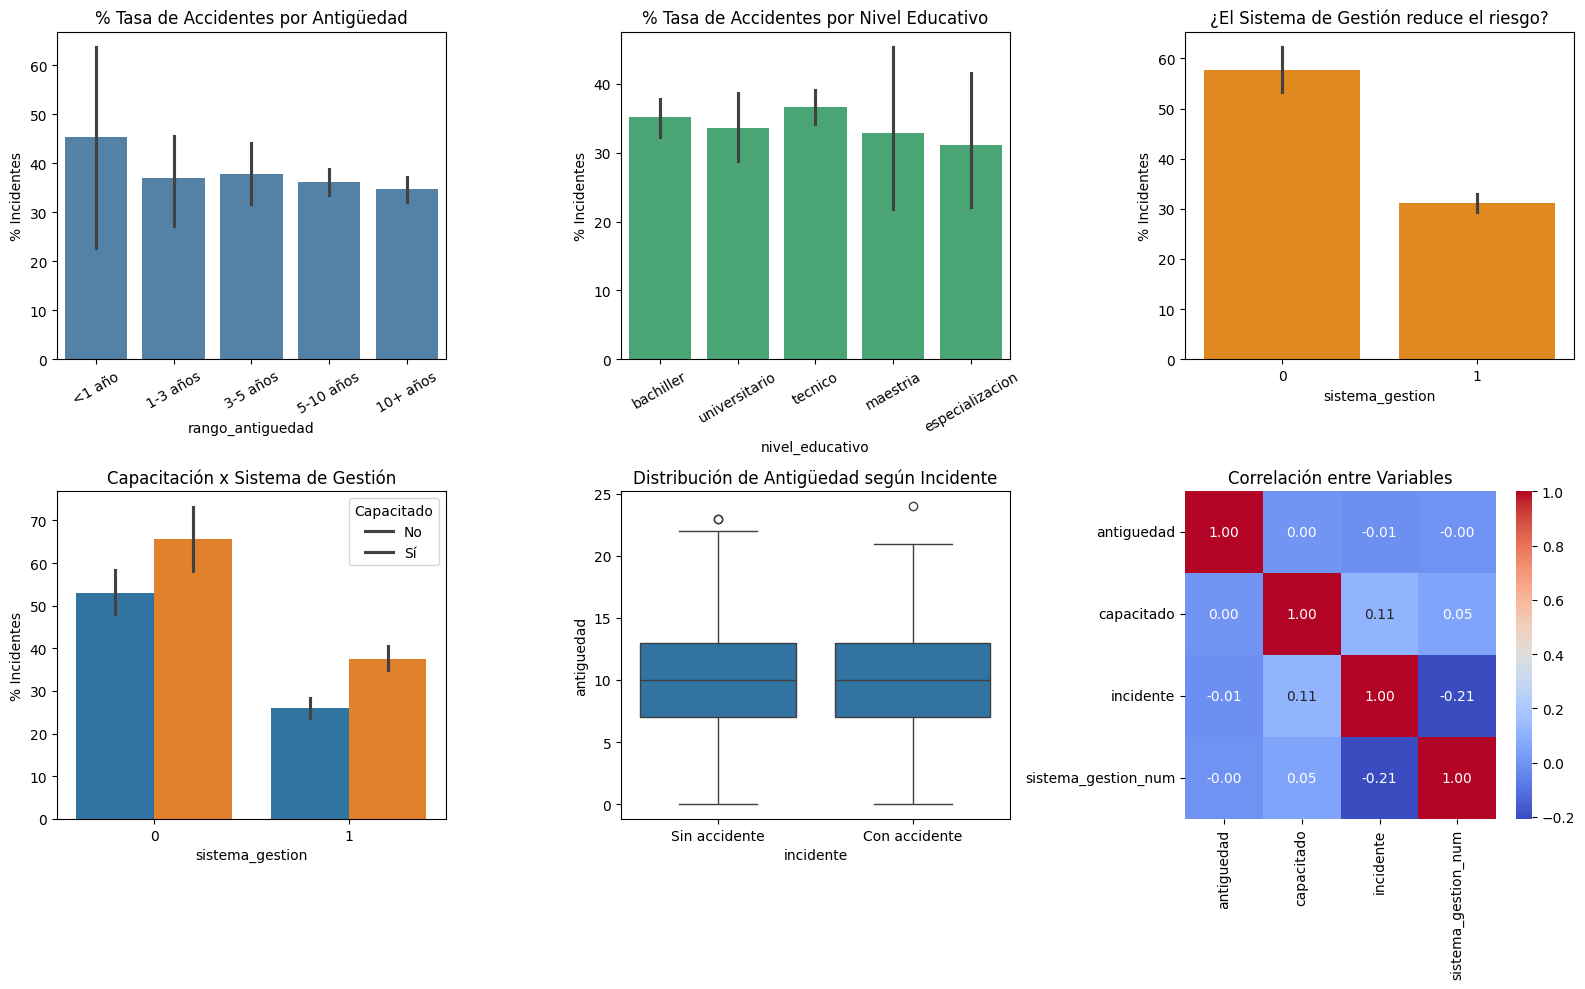

                 % Incidentes  N Trabajadores
sistema_gestion                              
0                       0.576             505
1                       0.311            2495
            % Incidentes  N Trabajadores
capacitado                              
0                  0.310            1721
1                  0.417            1279


In [ ]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# INSTRUCCIÓN: El estudiante debe generar otros gráficos que
# considere necesarios para profundizar en su análisis.
# Sugerencia: Explore la relación entre 'antiguedad', 'nivel_educativo' o
# 'sistema_gestion' respecto a la variable 'incidente'.

plt.figure(figsize=(16, 10))

# Gráfico 4: Antigüedad vs Incidente (agrupada en rangos)
plt.subplot(2, 3, 1)
df_final['rango_antiguedad'] = pd.cut(
    df_final['antiguedad'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=['<1 año', '1-3 años', '3-5 años', '5-10 años', '10+ años']
)
sns.barplot(data=df_final, x='rango_antiguedad', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, color='steelblue')
plt.title('% Tasa de Accidentes por Antigüedad')
plt.xticks(rotation=30)
plt.ylabel('% Incidentes')

# Gráfico 5: Nivel Educativo vs Incidente
plt.subplot(2, 3, 2)
sns.barplot(data=df_final, x='nivel_educativo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, color='mediumseagreen')
plt.title('% Tasa de Accidentes por Nivel Educativo')
plt.xticks(rotation=30)
plt.ylabel('% Incidentes')

# Gráfico 6: Sistema de Gestión vs Incidente
plt.subplot(2, 3, 3)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, color='darkorange')
plt.title('¿El Sistema de Gestión reduce el riesgo?')
plt.ylabel('% Incidentes')

# Gráfico 7: Cruce Capacitación x Sistema de Gestión (interacción)
plt.subplot(2, 3, 4)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente', hue='capacitado',
            estimator=lambda x: sum(x)/len(x)*100)
plt.title('Capacitación x Sistema de Gestión')
plt.ylabel('% Incidentes')
plt.legend(title='Capacitado', labels=['No', 'Sí'])

# Gráfico 8: Antigüedad vs Incidente (distribución, sin agrupar)
plt.subplot(2, 3, 5)
sns.boxplot(data=df_final, x='incidente', y='antiguedad')
plt.xticks([0, 1], ['Sin accidente', 'Con accidente'])
plt.title('Distribución de Antigüedad según Incidente')

# Gráfico 9: Mapa de calor de correlaciones (variables numéricas relevantes)
plt.subplot(2, 3, 6)
cols_num = ['antiguedad', 'capacitado', 'incidente']
# Si sistema_gestion/nivel_educativo son categóricas, se codifican para el heatmap
df_corr = df_final[cols_num].copy()
df_corr['sistema_gestion_num'] = df_final['sistema_gestion'].astype('category').cat.codes
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Variables')

plt.tight_layout()
plt.show()

# --- Tabla resumen numérica (útil para citar cifras en el informe ejecutivo) ---
resumen = df_final.groupby('sistema_gestion')['incidente'].agg(['mean', 'count']).round(3)
resumen.columns = ['% Incidentes', 'N Trabajadores']
print(resumen)

resumen_capacitacion = df_final.groupby('capacitado')['incidente'].agg(['mean', 'count']).round(3)
resumen_capacitacion.columns = ['% Incidentes', 'N Trabajadores']
print(resumen_capacitacion)

## Análisis

## Conclusiones